<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Arabic_Sentiment_Analysis_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Project 10: Arabic Sentiment Analysis

**Author:** Ahmed Vall Jemal Dine Sidina | AHMEDVALL70

**Context:** As a native Arabic speaker with diplomatic experience across Arabic-speaking communities, this project bridges linguistic expertise with AI — making NLP tools accessible for Arabic-language contexts.

**Goal:** Build an NLP model that classifies Arabic text into positive or negative sentiment using Machine Learning combined with Prompt Engineering techniques.

**Libraries:** Scikit-learn · Arabic NLP tools · Prompt Engineering

**Use Cases:** Arabic social media analysis · Public opinion mining · Sentiment monitoring

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 16.0 MB/s eta 0:00:00


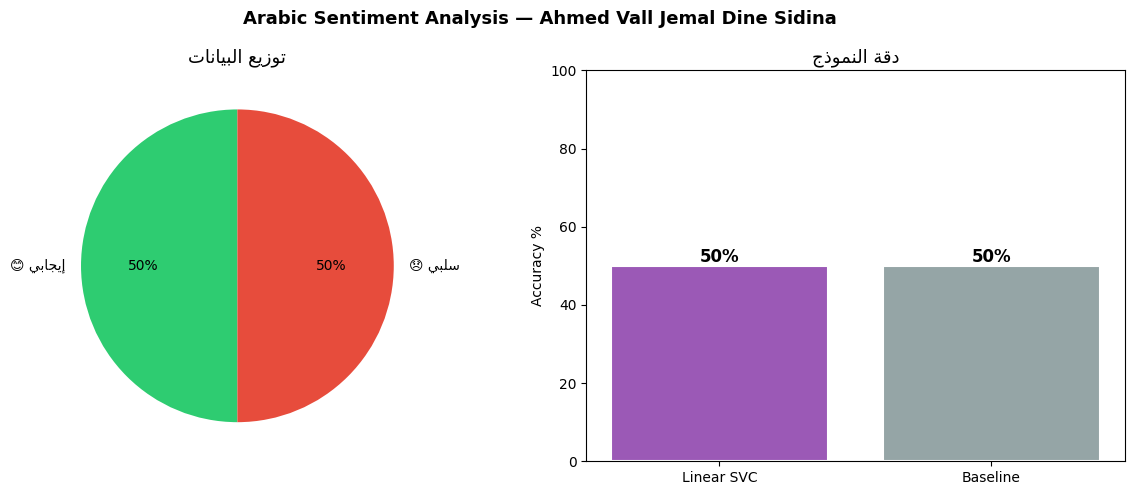

✅ تم! الدقة: 50.00%


In [1]:
!pip install arabic-reshaper python-bidi scikit-learn -q

import pandas as pd
import re
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def ar(text):
    return get_display(arabic_reshaper.reshape(text))

# البيانات
data = {
    'text': [
        'هذا المنتج رائع جداً وأنصح به الجميع',
        'خدمة ممتازة وسريعة شكراً جزيلاً',
        'تجربة جميلة سأكرر الشراء مرة أخرى',
        'جودة عالية وسعر مناسب أحسنتم',
        'فريق العمل محترف ومتعاون جداً',
        'أفضل تجربة تسوق في حياتي',
        'سعيد جداً بهذا الاختيار',
        'خدمة عملاء رائعة وسريعة الاستجابة',
        'نوعية ممتازة وتغليف احترافي',
        'تجربة ممتعة سأنصح أصدقائي بها',
        'منتج سيء جداً لا أنصح به أبداً',
        'خدمة بطيئة ومزعجة للغاية',
        'جودة رديئة لا تستحق السعر',
        'تجربة مروعة لن أكررها مطلقاً',
        'فريق العمل غير محترف ومهمل',
        'أسوأ تجربة تسوق في حياتي',
        'غير راضٍ عن هذا المنتج إطلاقاً',
        'خدمة عملاء سيئة لا تستجيب',
        'لن أشتري من هذا المتجر مجدداً',
        'مزيف وغير أصلي احذروا',
    ],
    'label': [1]*10 + [0]*10
}

df = pd.DataFrame(data)

def clean_arabic(text):
    text = re.sub(r'[\u064B-\u065F]', '', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    return text.strip()

df['text_clean'] = df['text'].apply(clean_arabic)

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['text_clean'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearSVC()
model.fit(X_train, y_train)
acc = accuracy_score(y_test, model.predict(X_test))

# الرسم البياني
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Arabic Sentiment Analysis — Ahmed Vall Jemal Dine Sidina',
             fontsize=13, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']
labels = [ar('إيجابي 😊'), ar('سلبي 😞')]
counts = [10, 10]
axes[0].pie(counts, labels=labels, colors=colors,
            autopct='%1.0f%%', startangle=90)
axes[0].set_title(ar('توزيع البيانات'), fontsize=13)

model_names = ['Linear SVC', 'Baseline']
accuracies = [acc * 100, 50]
bar_colors = ['#9b59b6', '#95a5a6']
bars = axes[1].bar(model_names, accuracies, color=bar_colors,
                    edgecolor='white', linewidth=1.5)
for bar, a in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{a:.0f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title(ar('دقة النموذج'), fontsize=13)
axes[1].set_ylabel('Accuracy %')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('sentiment_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ تم! الدقة: {acc:.2%}")